# PennyLane Export

**Model.** This notebook exports a three-site transverse-field Ising `DenseHamiltonian` and its Pauli-term metadata to PennyLane.

**Typical uses.** Verifying interoperability, preparing VQE/QPE prototypes, checking wire ordering, and confirming that exported Pauli sums preserve the package matrix.

**Parameters.** `n_sites`, Ising coupling `j`, transverse field `h`, and PennyLane `wire_order` determine the demonstrated export. PennyLane remains an optional dependency.

**Useful plots.** Package Hamiltonian magnitude and the absolute matrix difference after PennyLane reconstruction.

In [1]:
import importlib.util

import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.export import to_pennylane_terms
from quantum_lattice_models.models import transverse_field_ising

pennylane_available = importlib.util.find_spec("pennylane") is not None
print(f"PennyLane available: {pennylane_available}")

PennyLane available: True


In [2]:
H = transverse_field_ising(n_sites=3, j=1.0, h=0.5)
print("Package Hamiltonian")
print(f"  shape: {H.shape}")
print(f"  Pauli terms: {len(H.terms)}")
for term in H.terms:
    print(f"  {term.coefficient:+.2f} * {''.join(term.operators)}")

Package Hamiltonian
  shape: (8, 8)
  Pauli terms: 5
  -1.00 * ZZI
  -1.00 * IZZ
  -0.50 * XII
  -0.50 * IXI
  -0.50 * IIX


Export validation
  PennyLane terms: 5
  matrices agree: True
  max absolute difference: 0.000e+00


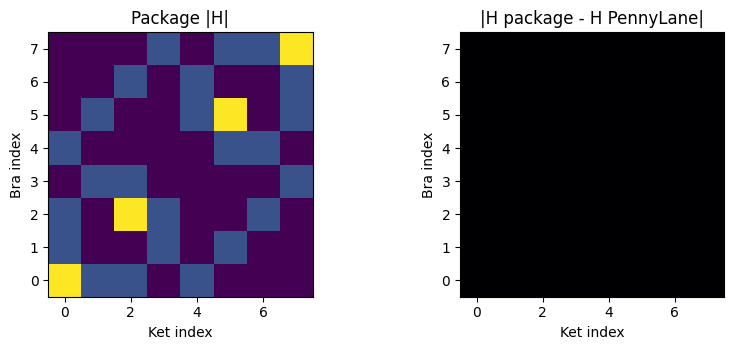

In [3]:
if pennylane_available:
    import pennylane as qml

    qml_H = to_pennylane_terms(H)
    qml_matrix = qml.matrix(qml_H, wire_order=range(H.n_sites))
    difference = np.asarray(H) - qml_matrix
    print("Export validation")
    print(f"  PennyLane terms: {len(qml_H.coeffs)}")
    print(f"  matrices agree: {np.allclose(H, qml_matrix)}")
    print(f"  max absolute difference: {np.max(np.abs(difference)):.3e}")

    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6))
    axes[0].imshow(np.abs(H), origin="lower", cmap="viridis")
    axes[0].set_title("Package |H|")
    axes[1].imshow(np.abs(difference), origin="lower", cmap="magma")
    axes[1].set_title("|H package - H PennyLane|")
    for ax in axes:
        ax.set_xlabel("Ket index")
        ax.set_ylabel("Bra index")
    fig.tight_layout()
else:
    print(
        "Install with `pip install quantum-lattice-models[pennylane]` "
        "to run the matrix comparison."
    )